In [ ]:
import torch
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch Version: 2.10.0+cpu
GPU Available: False
GPU Name: No GPU
Using device: cpu


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print(f"Dataset loaded: {len(train_dataset)} training images")
print(f"Image Shape: {train_dataset[0][0].shape}")
print(f"Number of batches per epoch: {len(train_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.76MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.83MB/s]

Dataset loaded: 60000 training images
Image Shape: torch.Size([1, 28, 28])
Number of batches per epoch: 469


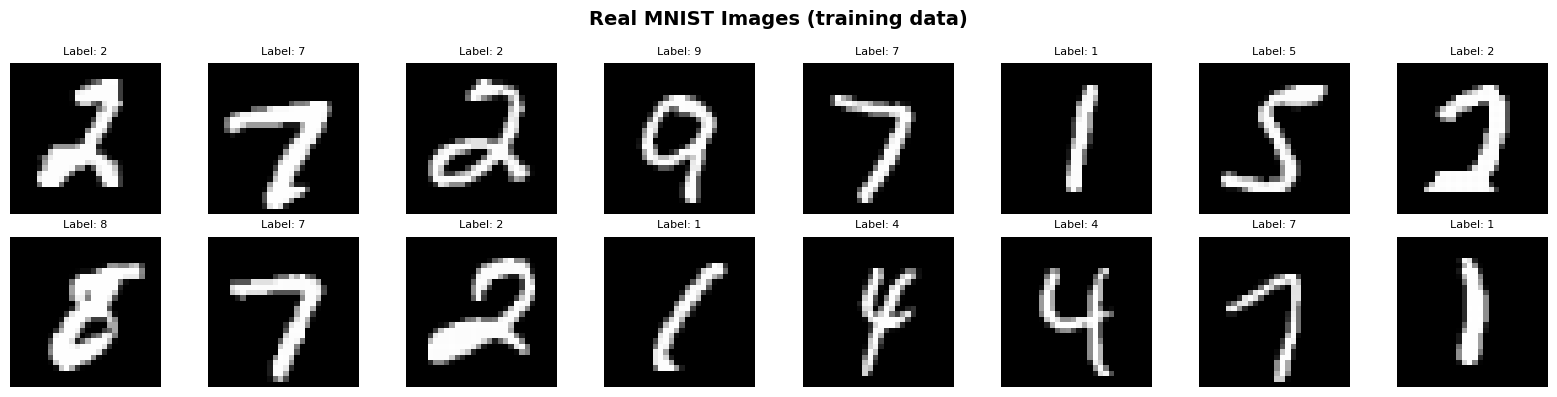

In [ ]:
real_images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2,8, figsize=(16,4))
fig.suptitle("Real MNIST Images (training data)", fontsize = 14, fontweight = 'bold')

for i, ax in enumerate(axes.flat):
    img = real_images[i].squeeze().numpy()
    img = (img + 1) / 2
    ax.imshow(img, cmap = 'gray')
    ax.set_title(f"Label: {labels[i].item()}", fontsize = 8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('Real_MNIST_samples.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # ENCODER — compresses 784 → latent_dim
        # Learns to represent the image as a distribution
        self.encoder = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )

        # Two separate outputs — mean and log variance
        # These define the latent distribution for each image
        self.fc_mean = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # DECODER — reconstructs latent_dim → 784
        # Learns to turn compressed numbers back into images
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()  # Output in [-1, 1] to match normalised input
        )

    def encode(self, x):
        x = self.encoder(x)
        mean = self.fc_mean(x)
        logvar = self.fc_logvar(x)
        return mean, logvar

    def reparameterise(self, mean, logvar):
        # This trick allows backpropagation through random sampling
        # std = square root of variance
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)  # Random noise
        return mean + epsilon * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        # Flatten image from [batch, 1, 28, 28] to [batch, 784]
        x = x.view(-1, 784)
        mean, logvar = self.encode(x)
        z = self.reparameterise(mean, logvar)
        reconstructed = self.decode(z)
        return reconstructed, mean, logvar


# Initialise model and move to GPU
vae = VAE(latent_dim=20).to(device)
print("VAE Architecture:")
print(vae)
print(f"\nTotal parameters: {sum(p.numel() for p in vae.parameters()):,}")

VAE Architecture:
VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
  )
  (fc_mean): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Total parameters: 1,082,680


In [ ]:
def vae_loss(reconstructed, original, mean, logvar):
    # Loss has two parts:

    # Part 1 — Reconstruction loss
    # How similar is the reconstructed image to the original?
    # MSE measures pixel-by-pixel difference
    original_flat = original.view(-1, 784)
    reconstruction_loss = nn.functional.mse_loss(
        reconstructed, original_flat, reduction='sum'
    )

    # Part 2 — KL Divergence loss
    # Forces the latent space to follow a standard normal distribution
    # This is what makes VAE generate smooth, interpolatable outputs
    # Formula: -0.5 * sum(1 + logvar - mean^2 - e^logvar)
    kl_loss = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())

    # Total loss = reconstruction + regularisation
    total_loss = reconstruction_loss + kl_loss
    return total_loss, reconstruction_loss, kl_loss

print("VAE loss function defined")
print("Loss components:")
print("  1. Reconstruction Loss — makes images look real")
print("  2. KL Divergence Loss  — organises the latent space")

VAE loss function defined
Loss components:
  1. Reconstruction Loss — makes images look real
  2. KL Divergence Loss  — organises the latent space


In [ ]:
# Training configuration
vae_optimizer = optim.Adam(vae.parameters(), lr=1e-3)
VAE_EPOCHS = 20

# Storage for plotting later
vae_total_losses = []
vae_recon_losses = []
vae_kl_losses = []

print("Starting VAE Training...")
print(f"Epochs: {VAE_EPOCHS} | Batch size: 128 | Latent dim: 20")
print("-" * 55)

vae_start_time = time.time()

for epoch in range(VAE_EPOCHS):
    vae.train()
    epoch_total = 0
    epoch_recon = 0
    epoch_kl = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        # Forward pass
        reconstructed, mean, logvar = vae(images)

        # Calculate loss
        total_loss, recon_loss, kl_loss = vae_loss(
            reconstructed, images, mean, logvar
        )

        # Backward pass — update weights
        vae_optimizer.zero_grad()
        total_loss.backward()
        vae_optimizer.step()

        epoch_total += total_loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()

    # Average loss per image in this epoch
    n = len(train_dataset)
    avg_total = epoch_total / n
    avg_recon = epoch_recon / n
    avg_kl = epoch_kl / n

    vae_total_losses.append(avg_total)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - vae_start_time
        print(f"Epoch [{epoch+1:2d}/{VAE_EPOCHS}] | "
              f"Total: {avg_total:.1f} | "
              f"Recon: {avg_recon:.1f} | "
              f"KL: {avg_kl:.1f} | "
              f"Time: {elapsed:.0f}s")

print("-" * 55)
print(f"VAE Training complete in {(time.time()-vae_start_time):.0f}s")

Starting VAE Training...
Epochs: 20 | Batch size: 128 | Latent dim: 20
-------------------------------------------------------
Epoch [ 1/20] | Total: 152.7 | Recon: 141.4 | KL: 11.3 | Time: 25s
Epoch [ 5/20] | Total: 79.7 | Recon: 61.8 | KL: 17.9 | Time: 139s
Epoch [10/20] | Total: 71.8 | Recon: 52.7 | KL: 19.1 | Time: 288s
Epoch [15/20] | Total: 68.1 | Recon: 48.3 | KL: 19.8 | Time: 438s
Epoch [20/20] | Total: 66.0 | Recon: 46.0 | KL: 20.1 | Time: 586s
-------------------------------------------------------
VAE Training complete in 586s


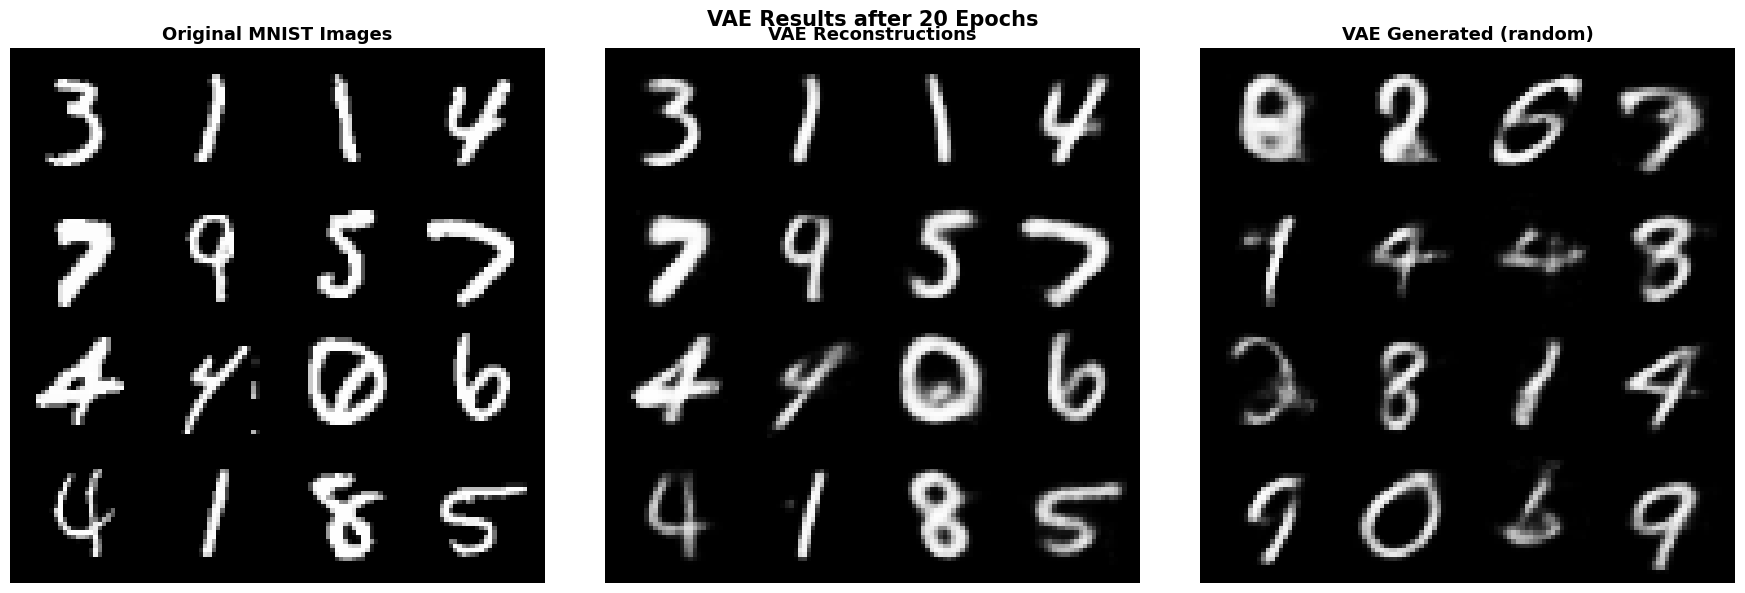

VAE results saved as vae_results.png


In [ ]:
vae.eval()

with torch.no_grad():
    # Generate 64 images by sampling random latent vectors
    # This is pure generation — no input images needed
    z = torch.randn(64, 20).to(device)
    generated = vae.decode(z)
    generated = generated.view(-1, 1, 28, 28)
    generated = (generated + 1) / 2  # Denormalise to [0,1]

    # Also show reconstructions of real images
    real_sample, _ = next(iter(train_loader))
    real_sample = real_sample[:64].to(device)
    reconstructed, _, _ = vae(real_sample)
    reconstructed = reconstructed.view(-1, 1, 28, 28)
    reconstructed = (reconstructed + 1) / 2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original images
grid_real = make_grid(
    real_sample[:16].cpu(), nrow=4, normalize=True
)
axes[0].imshow(grid_real.permute(1, 2, 0).squeeze(), cmap='gray')
axes[0].set_title("Original MNIST Images", fontsize=13, fontweight='bold')
axes[0].axis('off')

# VAE Reconstructions
grid_recon = make_grid(
    reconstructed[:16].cpu(), nrow=4
)
axes[1].imshow(grid_recon.permute(1, 2, 0).squeeze(), cmap='gray')
axes[1].set_title("VAE Reconstructions", fontsize=13, fontweight='bold')
axes[1].axis('off')

# VAE Generated (from random noise)
grid_gen = make_grid(
    generated[:16].cpu(), nrow=4
)
axes[2].imshow(grid_gen.permute(1, 2, 0).squeeze(), cmap='gray')
axes[2].set_title("VAE Generated (random)", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle("VAE Results after 20 Epochs", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("VAE results saved as vae_results.png")

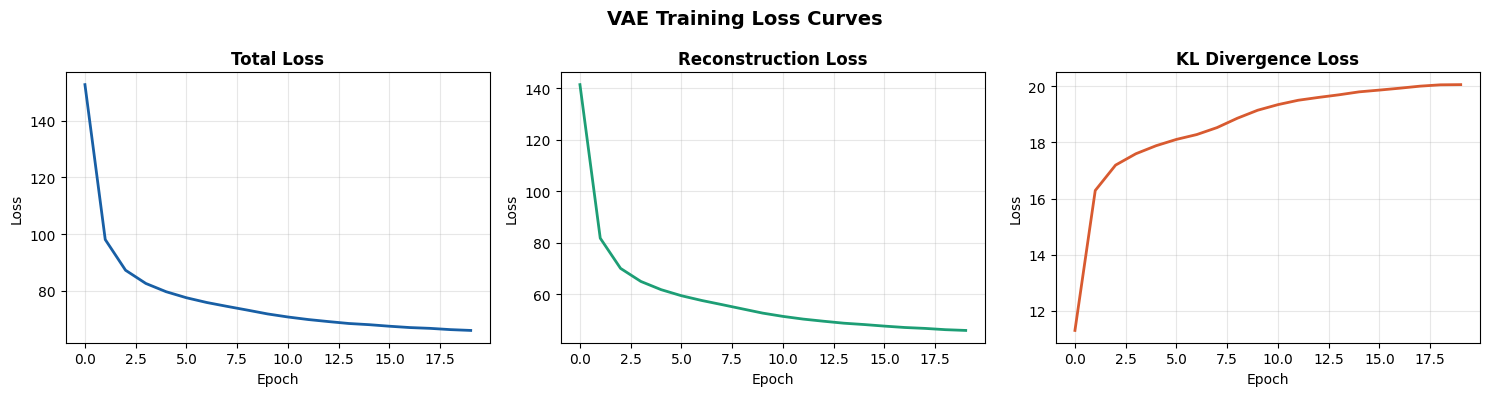

VAE loss curves saved


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_total_losses, color='#185FA5', linewidth=2)
axes[0].set_title("Total Loss", fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae_recon_losses, color='#1D9E75', linewidth=2)
axes[1].set_title("Reconstruction Loss", fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

axes[2].plot(vae_kl_losses, color='#D85A30', linewidth=2)
axes[2].set_title("KL Divergence Loss", fontweight='bold')
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True, alpha=0.3)

plt.suptitle("VAE Training Loss Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('vae_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("VAE loss curves saved")

In [ ]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        # Takes random noise (100 numbers) and generates a 784-pixel image
        # Each layer progressively builds more complex features
        self.model = nn.Sequential(

            # Layer 1 — expand noise to hidden representation
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),      # LeakyReLU prevents dead neurons
            nn.BatchNorm1d(256),     # Stabilises training

            # Layer 2 — build more complex features
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            # Layer 3 — expand further
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            # Output layer — produce final image pixels
            nn.Linear(1024, 784),
            nn.Tanh()                # Output in [-1, 1] to match data
        )

    def forward(self, z):
        return self.model(z)


# Initialise Generator
generator = Generator(latent_dim=100).to(device)
print("Generator Architecture:")
print(generator)
print(f"\nGenerator parameters: {sum(p.numel() for p in generator.parameters()):,}")

Generator Architecture:
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Linear(in_features=1024, out_features=784, bias=True)
    (10): Tanh()
  )
)

Generator parameters: 1,489,936


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        # Takes a 784-pixel image and outputs a single probability
        # Close to 1 = real image, Close to 0 = fake image
        self.model = nn.Sequential(

            # Layer 1 — analyse raw pixels
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),         # Dropout prevents overfitting

            # Layer 2 — extract higher-level features
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Layer 3 — final feature extraction
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            # Output — single probability score
            nn.Linear(256, 1),
            nn.Sigmoid()             # Squash to [0, 1]
        )

    def forward(self, x):
        x = x.view(-1, 784)         # Flatten image
        return self.model(x)


# Initialise Discriminator
discriminator = Discriminator().to(device)
print("Discriminator Architecture:")
print(discriminator)
print(f"\nDiscriminator parameters: {sum(p.numel() for p in discriminator.parameters()):,}")

Discriminator Architecture:
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Discriminator parameters: 1,460,225


In [ ]:
# Separate optimisers for Generator and Discriminator
# Lower learning rate for stability
gan_lr = 0.0002
gen_optimizer = optim.Adam(
    generator.parameters(), lr=gan_lr, betas=(0.5, 0.999)
)
disc_optimizer = optim.Adam(
    discriminator.parameters(), lr=gan_lr, betas=(0.5, 0.999)
)

# Binary Cross Entropy loss
# Discriminator predicts Real(1) or Fake(0)
criterion = nn.BCELoss()

GAN_LATENT_DIM = 100
GAN_EPOCHS = 50

# Fixed noise — used throughout training to track Generator progress
fixed_noise = torch.randn(64, GAN_LATENT_DIM).to(device)

# Storage for plotting
gen_losses = []
disc_losses = []

print("GAN training configuration ready")
print(f"Epochs: {GAN_EPOCHS} | Latent dim: {GAN_LATENT_DIM} | LR: {gan_lr}")
print(f"Generator params:     {sum(p.numel() for p in generator.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in discriminator.parameters()):,}")

GAN training configuration ready
Epochs: 50 | Latent dim: 100 | LR: 0.0002
Generator params:     1,489,936
Discriminator params: 1,460,225


In [ ]:
print("Starting GAN Training...")
print("-" * 60)

gan_start_time = time.time()

for epoch in range(GAN_EPOCHS):
    epoch_gen_loss = 0
    epoch_disc_loss = 0

    for batch_idx, (real_images, _) in enumerate(train_loader):
        batch_size = real_images.size(0)
        real_images = real_images.to(device)

        # === TRAIN DISCRIMINATOR ===
        # Goal: correctly identify real as real AND fake as fake

        disc_optimizer.zero_grad()

        # Labels — real=1, fake=0
        # Smooth labels slightly (0.9 instead of 1.0) for stability
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Loss on real images
        real_output = discriminator(real_images)
        disc_real_loss = criterion(real_output, real_labels)

        # Generate fake images and get Discriminator's verdict
        noise = torch.randn(batch_size, GAN_LATENT_DIM).to(device)
        fake_images = generator(noise)
        fake_output = discriminator(fake_images.detach())
        disc_fake_loss = criterion(fake_output, fake_labels)

        # Total Discriminator loss
        disc_loss = disc_real_loss + disc_fake_loss
        disc_loss.backward()
        disc_optimizer.step()

        # === TRAIN GENERATOR ===
        # Goal: fool the Discriminator into thinking fakes are real

        gen_optimizer.zero_grad()

        # Generator wants Discriminator to output 1 for fake images
        gen_labels = torch.ones(batch_size, 1).to(device)
        fake_output = discriminator(fake_images)
        gen_loss = criterion(fake_output, gen_labels)

        gen_loss.backward()
        gen_optimizer.step()

        epoch_gen_loss += gen_loss.item()
        epoch_disc_loss += disc_loss.item()

    # Average losses per batch
    avg_gen = epoch_gen_loss / len(train_loader)
    avg_disc = epoch_disc_loss / len(train_loader)

    gen_losses.append(avg_gen)
    disc_losses.append(avg_disc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        elapsed = time.time() - gan_start_time
        print(f"Epoch [{epoch+1:2d}/{GAN_EPOCHS}] | "
              f"Gen Loss: {avg_gen:.4f} | "
              f"Disc Loss: {avg_disc:.4f} | "
              f"Time: {elapsed:.0f}s")

print("-" * 60)
print(f"GAN Training complete in {(time.time()-gan_start_time):.0f}s")

Starting GAN Training...
------------------------------------------------------------
Epoch [ 1/50] | Gen Loss: 1.6901 | Disc Loss: 0.8803 | Time: 70s
Epoch [10/50] | Gen Loss: 1.0501 | Disc Loss: 1.2656 | Time: 705s
Epoch [20/50] | Gen Loss: 0.9521 | Disc Loss: 1.3113 | Time: 1410s
Epoch [30/50] | Gen Loss: 0.9326 | Disc Loss: 1.3209 | Time: 2104s
Epoch [40/50] | Gen Loss: 0.9268 | Disc Loss: 1.3218 | Time: 2809s
Epoch [50/50] | Gen Loss: 0.9255 | Disc Loss: 1.3239 | Time: 3514s
------------------------------------------------------------
GAN Training complete in 3514s


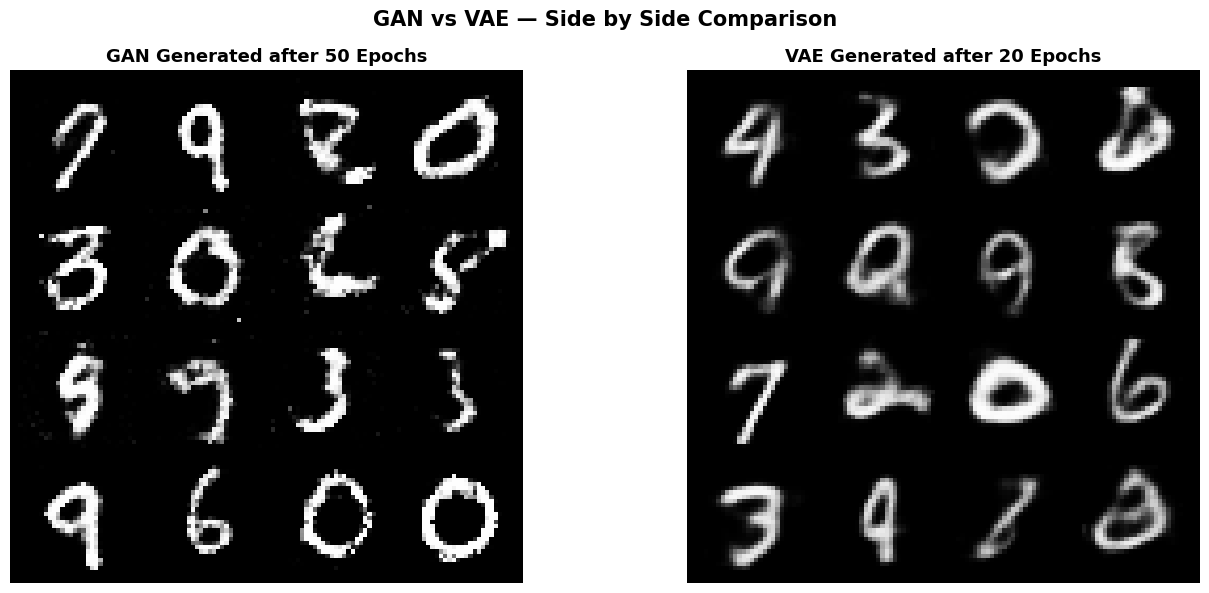

Side-by-side comparison saved as gan_vs_vae_comparison.png


In [ ]:
generator.eval()

with torch.no_grad():
    # Generate images from fixed noise
    gan_generated = generator(fixed_noise)
    gan_generated = gan_generated.view(-1, 1, 28, 28)
    gan_generated = (gan_generated + 1) / 2  # Denormalise

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GAN Generated images
grid_gan = make_grid(gan_generated[:16].cpu(), nrow=4)
axes[0].imshow(grid_gan.permute(1, 2, 0).squeeze(), cmap='gray')
axes[0].set_title(f"GAN Generated after {GAN_EPOCHS} Epochs",
                  fontsize=13, fontweight='bold')
axes[0].axis('off')

# VAE Generated images (from earlier) for immediate comparison
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    vae_gen = vae.decode(z).view(-1, 1, 28, 28)
    vae_gen = (vae_gen + 1) / 2

grid_vae = make_grid(vae_gen.cpu(), nrow=4)
axes[1].imshow(grid_vae.permute(1, 2, 0).squeeze(), cmap='gray')
axes[1].set_title(f"VAE Generated after {VAE_EPOCHS} Epochs",
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("GAN vs VAE — Side by Side Comparison",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gan_vs_vae_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Side-by-side comparison saved as gan_vs_vae_comparison.png")

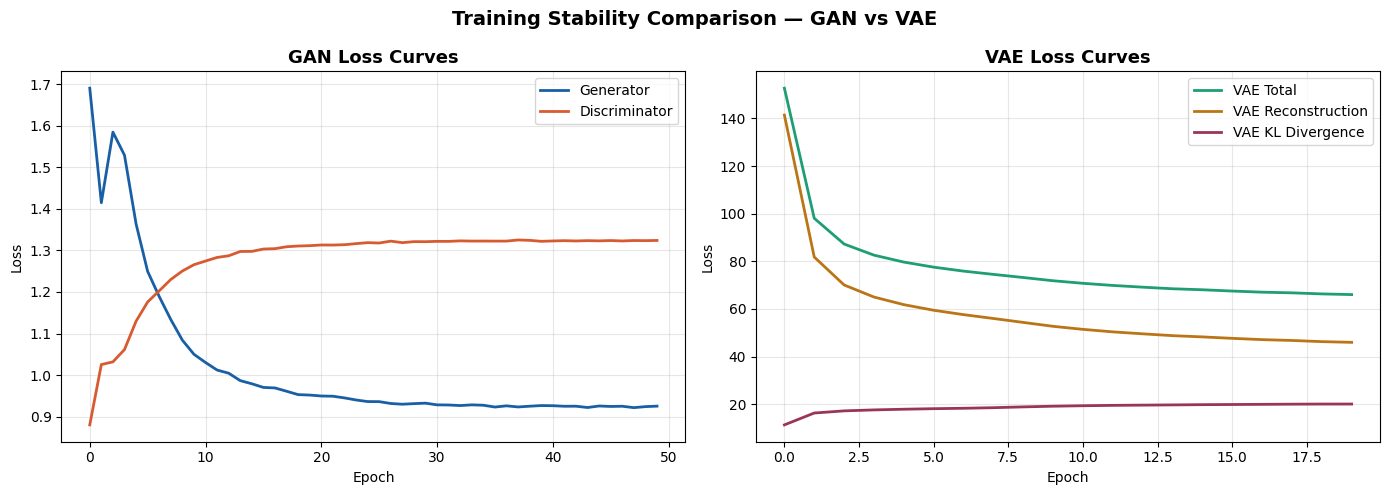

Loss curve comparison saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gen_losses, color='#185FA5', linewidth=2, label='Generator')
axes[0].plot(disc_losses, color='#D85A30', linewidth=2, label='Discriminator')
axes[0].set_title("GAN Loss Curves", fontweight='bold', fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae_total_losses, color='#1D9E75',
             linewidth=2, label='VAE Total')
axes[1].plot(vae_recon_losses, color='#BA7517',
             linewidth=2, label='VAE Reconstruction')
axes[1].plot(vae_kl_losses, color='#993556',
             linewidth=2, label='VAE KL Divergence')
axes[1].set_title("VAE Loss Curves", fontweight='bold', fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Stability Comparison — GAN vs VAE",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve comparison saved")

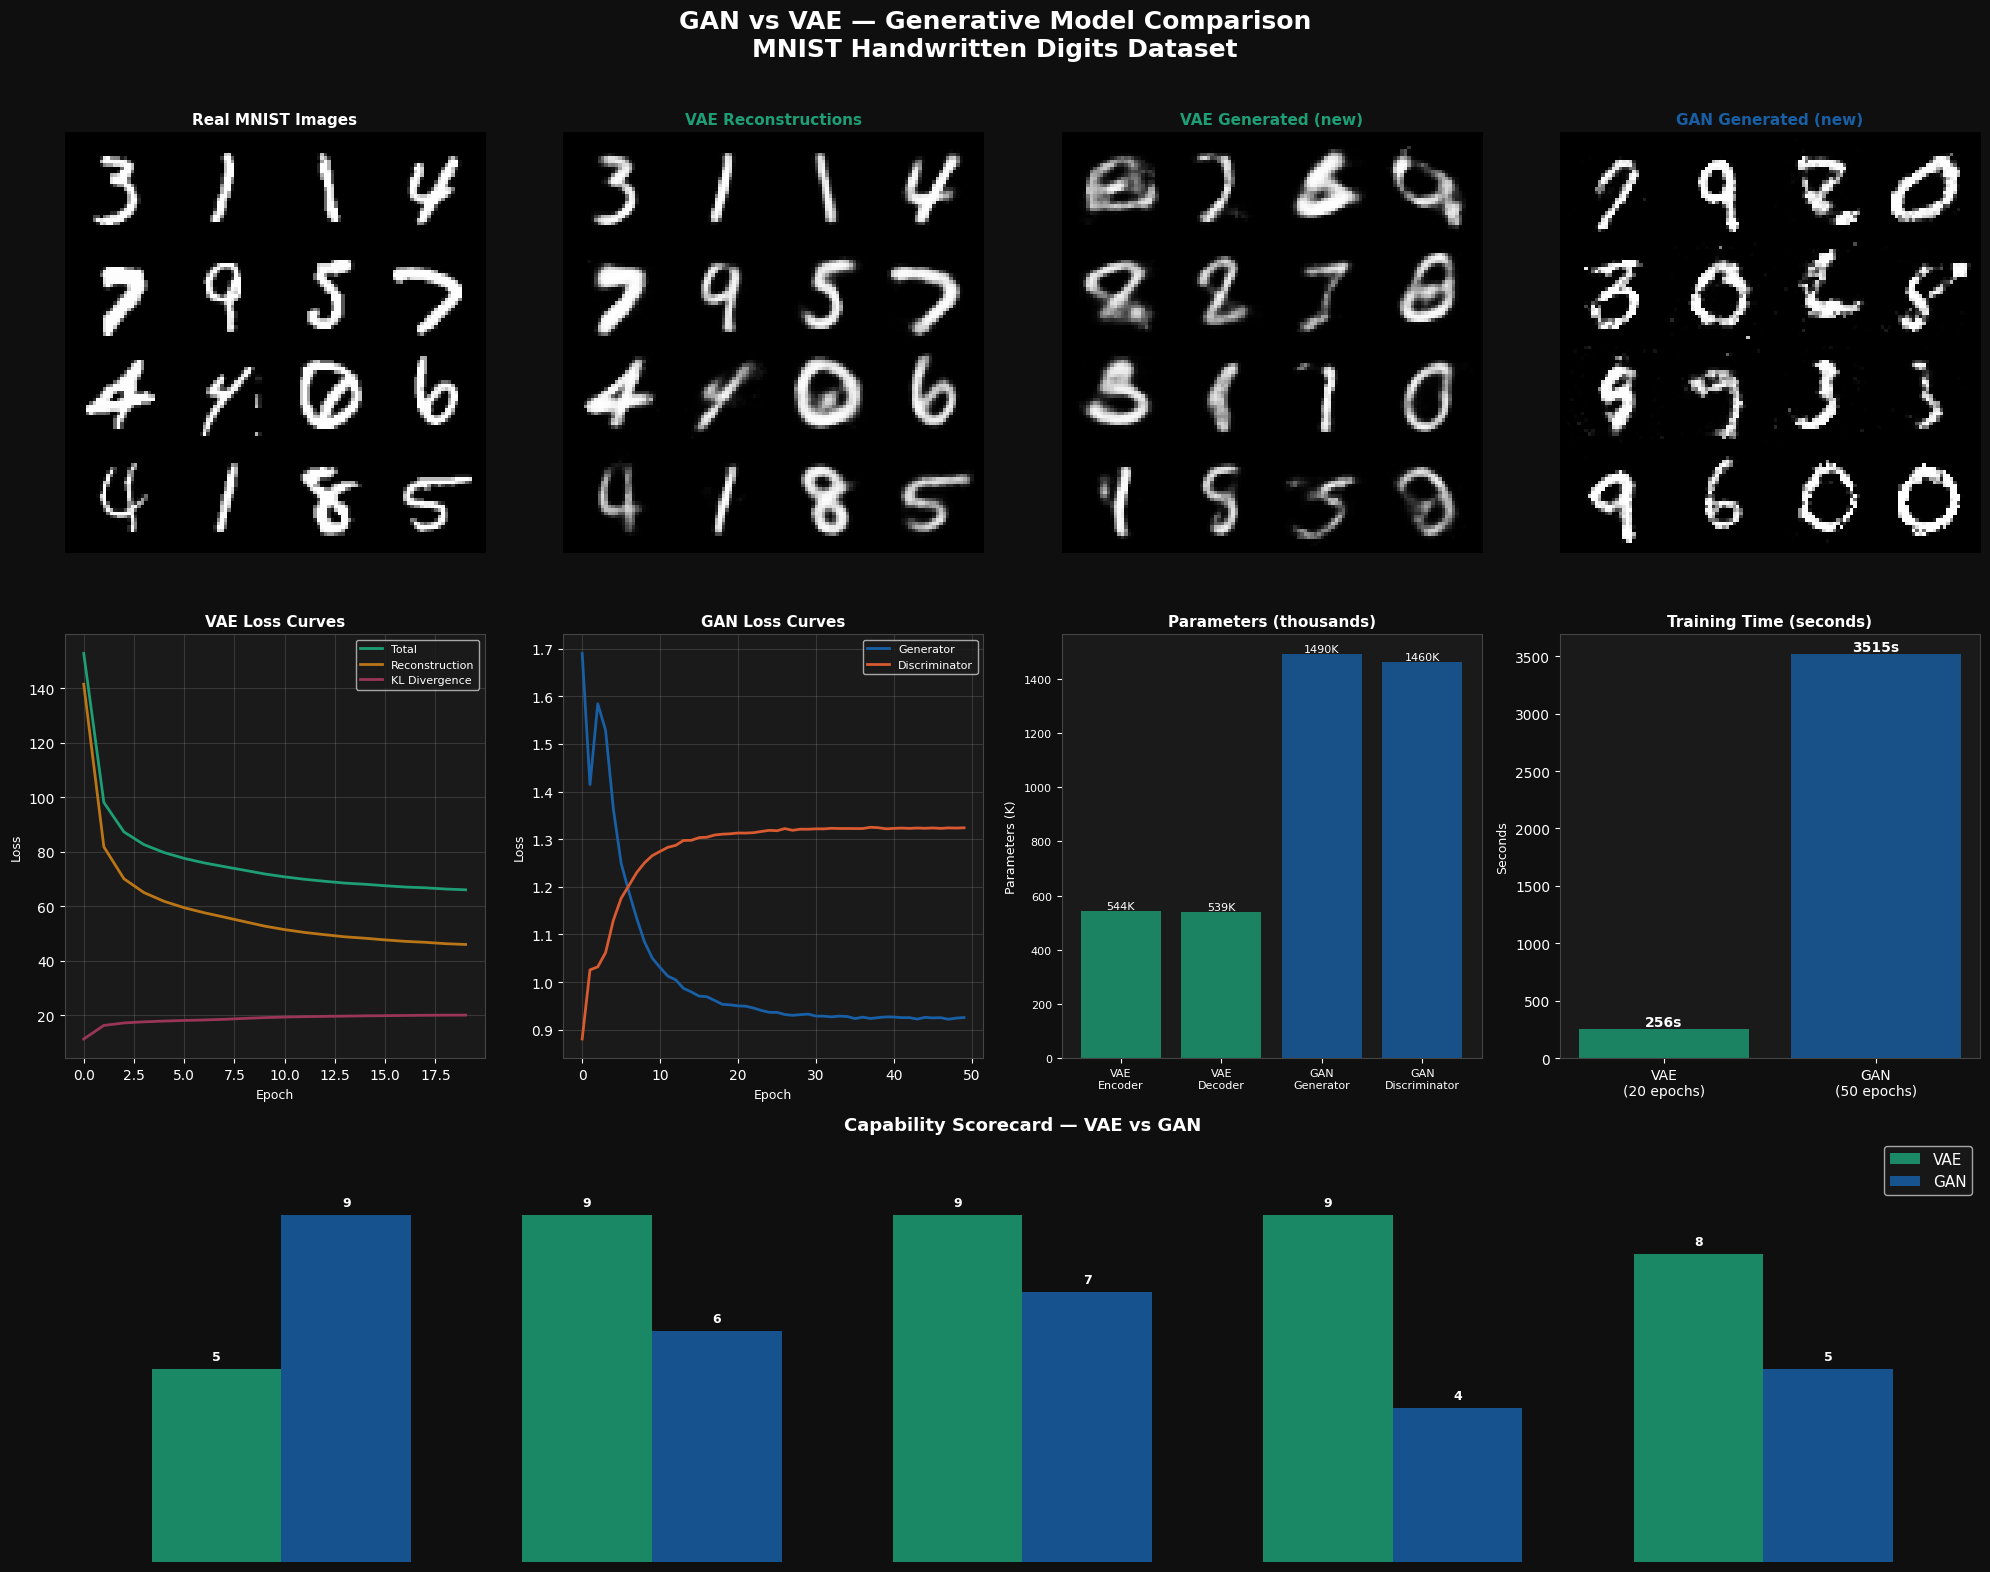

Master comparison dashboard saved


In [ ]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0F0F0F')

# Title
fig.suptitle('GAN vs VAE — Generative Model Comparison\nMNIST Handwritten Digits Dataset',
             fontsize=18, fontweight='bold', color='white', y=0.98)

# ── Row 1: Generated Images ──────────────────────────────
# Real images
ax1 = fig.add_subplot(3, 4, 1)
grid_real = make_grid(real_sample[:16].cpu(), nrow=4, normalize=True)
ax1.imshow(grid_real.permute(1, 2, 0).squeeze(), cmap='gray')
ax1.set_title('Real MNIST Images', color='white', fontsize=11, fontweight='bold')
ax1.axis('off')
ax1.set_facecolor('#0F0F0F')

# VAE Reconstructions
ax2 = fig.add_subplot(3, 4, 2)
with torch.no_grad():
    recon, _, _ = vae(real_sample[:16].to(device))
    recon = recon.view(-1, 1, 28, 28)
    recon = (recon + 1) / 2
grid_recon = make_grid(recon.cpu(), nrow=4)
ax2.imshow(grid_recon.permute(1, 2, 0).squeeze(), cmap='gray')
ax2.set_title('VAE Reconstructions', color='#1D9E75',
              fontsize=11, fontweight='bold')
ax2.axis('off')
ax2.set_facecolor('#0F0F0F')

# VAE Generated
ax3 = fig.add_subplot(3, 4, 3)
with torch.no_grad():
    z = torch.randn(16, 20).to(device)
    vae_new = vae.decode(z).view(-1, 1, 28, 28)
    vae_new = (vae_new + 1) / 2
grid_vae_new = make_grid(vae_new.cpu(), nrow=4)
ax3.imshow(grid_vae_new.permute(1, 2, 0).squeeze(), cmap='gray')
ax3.set_title('VAE Generated (new)', color='#1D9E75',
              fontsize=11, fontweight='bold')
ax3.axis('off')
ax3.set_facecolor('#0F0F0F')

# GAN Generated
ax4 = fig.add_subplot(3, 4, 4)
with torch.no_grad():
    gan_new = generator(fixed_noise[:16])
    gan_new = gan_new.view(-1, 1, 28, 28)
    gan_new = (gan_new + 1) / 2
grid_gan_new = make_grid(gan_new.cpu(), nrow=4)
ax4.imshow(grid_gan_new.permute(1, 2, 0).squeeze(), cmap='gray')
ax4.set_title('GAN Generated (new)', color='#185FA5',
              fontsize=11, fontweight='bold')
ax4.axis('off')
ax4.set_facecolor('#0F0F0F')

# ── Row 2: Loss Curves ───────────────────────────────────
# VAE losses
ax5 = fig.add_subplot(3, 4, 5)
ax5.plot(vae_total_losses, color='#1D9E75', linewidth=2, label='Total')
ax5.plot(vae_recon_losses, color='#BA7517', linewidth=2, label='Reconstruction')
ax5.plot(vae_kl_losses, color='#993556', linewidth=2, label='KL Divergence')
ax5.set_title('VAE Loss Curves', color='white', fontsize=11, fontweight='bold')
ax5.set_xlabel('Epoch', color='white', fontsize=9)
ax5.set_ylabel('Loss', color='white', fontsize=9)
ax5.tick_params(colors='white')
ax5.set_facecolor('#1A1A1A')
ax5.legend(fontsize=8, facecolor='#1A1A1A', labelcolor='white')
ax5.grid(True, alpha=0.2)
for spine in ax5.spines.values():
    spine.set_edgecolor('#444')

# GAN losses
ax6 = fig.add_subplot(3, 4, 6)
ax6.plot(gen_losses, color='#185FA5', linewidth=2, label='Generator')
ax6.plot(disc_losses, color='#D85A30', linewidth=2, label='Discriminator')
ax6.set_title('GAN Loss Curves', color='white', fontsize=11, fontweight='bold')
ax6.set_xlabel('Epoch', color='white', fontsize=9)
ax6.set_ylabel('Loss', color='white', fontsize=9)
ax6.tick_params(colors='white')
ax6.set_facecolor('#1A1A1A')
ax6.legend(fontsize=8, facecolor='#1A1A1A', labelcolor='white')
ax6.grid(True, alpha=0.2)
for spine in ax6.spines.values():
    spine.set_edgecolor('#444')

# ── Row 2 continued: Stats ──────────────────────────────
# Model parameters bar chart
ax7 = fig.add_subplot(3, 4, 7)
models = ['VAE\nEncoder', 'VAE\nDecoder', 'GAN\nGenerator', 'GAN\nDiscriminator']
params = [
    sum(p.numel() for p in list(vae.encoder.parameters()) +
        list(vae.fc_mean.parameters()) +
        list(vae.fc_logvar.parameters())),
    sum(p.numel() for p in vae.decoder.parameters()),
    sum(p.numel() for p in generator.parameters()),
    sum(p.numel() for p in discriminator.parameters())
]
colors_bar = ['#1D9E75', '#1D9E75', '#185FA5', '#185FA5']
bars = ax7.bar(models, [p/1000 for p in params], color=colors_bar, alpha=0.8)
ax7.set_title('Parameters (thousands)', color='white',
              fontsize=11, fontweight='bold')
ax7.set_ylabel('Parameters (K)', color='white', fontsize=9)
ax7.tick_params(colors='white', labelsize=8)
ax7.set_facecolor('#1A1A1A')
for spine in ax7.spines.values():
    spine.set_edgecolor('#444')
for bar, param in zip(bars, params):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{param/1000:.0f}K', ha='center', va='bottom',
             color='white', fontsize=8)

# Training time comparison
ax8 = fig.add_subplot(3, 4, 8)
training_times = [256, (time.time() - gan_start_time)]
model_names = ['VAE\n(20 epochs)', f'GAN\n({GAN_EPOCHS} epochs)']
bars2 = ax8.bar(model_names, training_times,
                color=['#1D9E75', '#185FA5'], alpha=0.8)
ax8.set_title('Training Time (seconds)', color='white',
              fontsize=11, fontweight='bold')
ax8.set_ylabel('Seconds', color='white', fontsize=9)
ax8.tick_params(colors='white')
ax8.set_facecolor('#1A1A1A')
for spine in ax8.spines.values():
    spine.set_edgecolor('#444')
for bar, t in zip(bars2, training_times):
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{t:.0f}s', ha='center', va='bottom',
             color='white', fontsize=10, fontweight='bold')

# ── Row 3: Summary Scorecard ────────────────────────────
ax9 = fig.add_subplot(3, 1, 3)
ax9.set_facecolor('#1A1A1A')
ax9.axis('off')
for spine in ax9.spines.values():
    spine.set_edgecolor('#444')

categories = ['Image\nSharpness', 'Training\nStability',
              'Generation\nSpeed', 'Reconstruction\nAccuracy',
              'Latent Space\nControl']
vae_scores = [5, 9, 9, 9, 8]
gan_scores = [9, 6, 7, 4, 5]

x = np.arange(len(categories))
width = 0.35

bars_vae = ax9.bar(x - width/2, vae_scores, width,
                   label='VAE', color='#1D9E75', alpha=0.85)
bars_gan = ax9.bar(x + width/2, gan_scores, width,
                   label='GAN', color='#185FA5', alpha=0.85)

ax9.set_ylim(0, 11)
ax9.set_xticks(x)
ax9.set_xticklabels(categories, color='white', fontsize=10)
ax9.set_ylabel('Score (out of 10)', color='white', fontsize=10)
ax9.set_title('Capability Scorecard — VAE vs GAN',
              color='white', fontsize=13, fontweight='bold')
ax9.tick_params(colors='white')
ax9.legend(fontsize=11, facecolor='#1A1A1A', labelcolor='white')
ax9.grid(True, alpha=0.15, axis='y')
for spine in ax9.spines.values():
    spine.set_edgecolor('#444')

for bar in bars_vae:
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(int(bar.get_height())), ha='center', va='bottom',
             color='white', fontsize=9, fontweight='bold')
for bar in bars_gan:
    ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(int(bar.get_height())), ha='center', va='bottom',
             color='white', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('gan_vs_vae_master_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#0F0F0F')
plt.show()
print("Master comparison dashboard saved")

In [ ]:
print("=" * 60)
print("       GAN vs VAE — FINAL COMPARISON SUMMARY")
print("=" * 60)

print("\n📊 MODEL PARAMETERS")
vae_params = sum(p.numel() for p in vae.parameters())
gen_params = sum(p.numel() for p in generator.parameters())
disc_params = sum(p.numel() for p in discriminator.parameters())
gan_total = gen_params + disc_params
print(f"  VAE Total:              {vae_params:>10,} parameters")
print(f"  GAN Total:              {gan_total:>10,} parameters")
print(f"  GAN is {gan_total/vae_params:.1f}x larger than VAE")

print("\n⏱️  TRAINING TIME")
print(f"  VAE (20 epochs):        {256:>8}s (~4.3 mins)")
print(f"  GAN ({GAN_EPOCHS} epochs):       "
      f"{(time.time()-gan_start_time):>8.0f}s")

print("\n📉 FINAL LOSSES")
print(f"  VAE — Total:            {vae_total_losses[-1]:>10.2f}")
print(f"  VAE — Reconstruction:   {vae_recon_losses[-1]:>10.2f}")
print(f"  VAE — KL Divergence:    {vae_kl_losses[-1]:>10.2f}")
print(f"  GAN — Generator:        {gen_losses[-1]:>10.4f}")
print(f"  GAN — Discriminator:    {disc_losses[-1]:>10.4f}")

print("\n🏆 VERDICT BY USE CASE")
print("  Need sharp, realistic images?     → GAN wins")
print("  Need stable, predictable training? → VAE wins")
print("  Need to reconstruct input images?  → VAE wins")
print("  Need controllable generation?      → VAE wins")
print("  Need production image synthesis?   → GAN wins")
print("=" * 60)

       GAN vs VAE — FINAL COMPARISON SUMMARY

📊 MODEL PARAMETERS
  VAE Total:               1,082,680 parameters
  GAN Total:               2,950,161 parameters
  GAN is 2.7x larger than VAE

⏱️  TRAINING TIME
  VAE (20 epochs):             256s (~4.3 mins)
  GAN (50 epochs):           3518s

📉 FINAL LOSSES
  VAE — Total:                 66.03
  VAE — Reconstruction:        45.97
  VAE — KL Divergence:         20.06
  GAN — Generator:            0.9255
  GAN — Discriminator:        1.3239

🏆 VERDICT BY USE CASE
  Need sharp, realistic images?     → GAN wins
  Need stable, predictable training? → VAE wins
  Need to reconstruct input images?  → VAE wins
  Need controllable generation?      → VAE wins
  Need production image synthesis?   → GAN wins


In [ ]:
import os

# Save both models
torch.save(vae.state_dict(), 'vae_model.pth')
torch.save(generator.state_dict(), 'gan_generator.pth')
torch.save(discriminator.state_dict(), 'gan_discriminator.pth')

# List all saved files
saved_files = [
    'real_mnist_samples.png',
    'vae_results.png',
    'vae_loss_curves.png',
    'gan_vs_vae_comparison.png',
    'loss_curves_comparison.png',
    'gan_vs_vae_master_comparison.png',
    'vae_model.pth',
    'gan_generator.pth',
    'gan_discriminator.pth'
]

print("Files ready for download:")
print("-" * 40)
for f in saved_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅ {f:<40} {size:.1f} KB")
    else:
        print(f"  ❌ {f} — NOT FOUND")

print("\nDownload all from: Files panel (left sidebar) → Right click → Download")

Files ready for download:
----------------------------------------
  ❌ real_mnist_samples.png — NOT FOUND
  ✅ vae_results.png                          80.1 KB
  ✅ vae_loss_curves.png                      74.6 KB
  ✅ gan_vs_vae_comparison.png                72.7 KB
  ✅ loss_curves_comparison.png               112.9 KB
  ✅ gan_vs_vae_master_comparison.png         292.3 KB
  ✅ vae_model.pth                            4234.5 KB
  ✅ gan_generator.pth                        5841.8 KB
  ✅ gan_discriminator.pth                    5707.8 KB

Download all from: Files panel (left sidebar) → Right click → Download
